In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import zscore

import warnings
warnings.filterwarnings("ignore")

In [2]:
print("Week - 01")

df = pd.read_csv("//kaggle/input/fraud-detection/fraudTrain.csv")
print("\nFirst five rows:\n")
print(df.head())
print("\nLast five rows :\n")
print(df.tail())
print("\nColumn names :\n")
print(df.columns)
print("\nnumber of rows and columns:\n")
print(df.shape)
print("\nInfo :")
print(df.info())

Week - 01

First five rows:

   Unnamed: 0 trans_date_trans_time            cc_num  \
0           0   2019-01-01 00:00:18  2703186189652095   
1           1   2019-01-01 00:00:44      630423337322   
2           2   2019-01-01 00:00:51    38859492057661   
3           3   2019-01-01 00:01:16  3534093764340240   
4           4   2019-01-01 00:03:06   375534208663984   

                             merchant       category     amt      first  \
0          fraud_Rippin, Kub and Mann       misc_net    4.97   Jennifer   
1     fraud_Heller, Gutmann and Zieme    grocery_pos  107.23  Stephanie   
2                fraud_Lind-Buckridge  entertainment  220.11     Edward   
3  fraud_Kutch, Hermiston and Farrell  gas_transport   45.00     Jeremy   
4                 fraud_Keeling-Crist       misc_pos   41.96      Tyler   

      last gender                        street  ...      lat      long  \
0    Banks      F                561 Perry Cove  ...  36.0788  -81.1781   
1     Gill      F  43039 Ri

Week - 02

Data types :

Unnamed: 0                 int64
trans_date_trans_time     object
cc_num                     int64
merchant                  object
category                  object
amt                      float64
first                     object
last                      object
gender                    object
street                    object
city                      object
state                     object
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                       object
dob                       object
trans_num                 object
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object




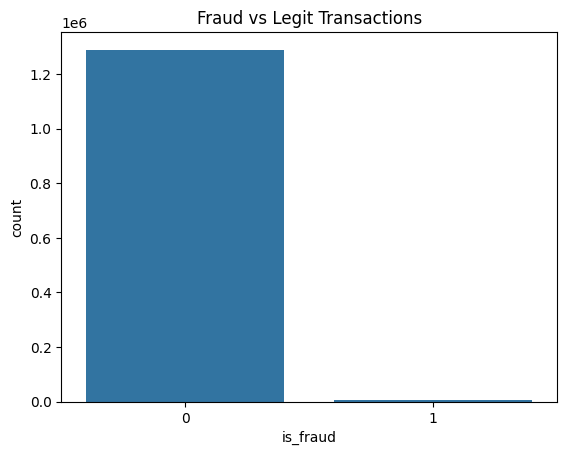


Data Quality Report



,Data_Type,Missing_Values,Missing_%,Unique_Values
Unnamed: 0,int64,0,0.0,1296675
trans_date_trans_time,object,0,0.0,1274791
cc_num,int64,0,0.0,983
merchant,object,0,0.0,693
category,object,0,0.0,14
amt,float64,0,0.0,52928
first,object,0,0.0,352
last,object,0,0.0,481
gender,object,0,0.0,2
street,object,0,0.0,983


In [3]:
print("Week - 02")

print("\nData types :\n")
print(df.dtypes)
print("\n")
missing_report = df.isnull().sum().to_frame(name="Missing_Count")
missing_report["Missing_%"] = (missing_report["Missing_Count"] / len(df)) * 100
missing_report.sort_values(by="Missing_%", ascending=False)
df['is_fraud'].value_counts(normalize=True) * 100
sns.countplot(x='is_fraud', data=df)
plt.title("Fraud vs Legit Transactions")
plt.show()

df.describe()
def data_quality_report(data):
    report = pd.DataFrame({
        "Data_Type": data.dtypes,
        "Missing_Values": data.isnull().sum(),
        "Missing_%": (data.isnull().sum() / len(data)) * 100,
        "Unique_Values": data.nunique()
    })
    return report

dq_report = data_quality_report(df)
print("\nData Quality Report\n")
dq_report


Week - 03

Feature Engineering

Dataset after Feature Engineering
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 25 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   trans_date_trans_time  1296675 non-null  datetime64[ns]
 1   cc_num                 1296675 non-null  int64         
 2   merchant               1296675 non-null  object        
 3   category               1296675 non-null  object        
 4   amt                    1296675 non-null  float64       
 5   first                  1296675 non-null  object        
 6   last                   1296675 non-null  object        
 7   gender                 1296675 non-null  object        
 8   street                 1296675 non-null  object        
 9   city                   1296675 non-null  object        
 10  state                  1296675 non-null  object        
 11  zip                    

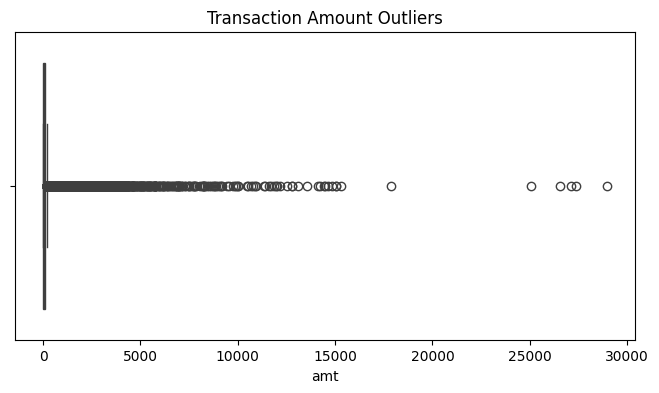


Outlier Detection using Z-score (12738, 26)


In [4]:
print("Week - 03")

df.drop(columns=['Unnamed: 0'], inplace=True)

print("\nFeature Engineering\n")
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['hour'] = df['trans_date_trans_time'].dt.hour
df['day'] = df['trans_date_trans_time'].dt.day
df['month'] = df['trans_date_trans_time'].dt.month

print("Dataset after Feature Engineering")
df[['trans_date_trans_time', 'hour', 'day', 'month']].head()
print("Info : ",df.info())
print("Columns : ",df.columns)


print("\nHandling Missing Values\n")
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)
print(df.isnull().sum())

print("\nOutlier Detection using IQR")
Q1 = df['amt'].quantile(0.25)
Q3 = df['amt'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['amt'] < lower) | (df['amt'] > upper)]
outliers.shape
print("Number of Outliers Detected:", outliers.shape[0])
outliers[['amt']].head()


print("\nOutlier Visualization - Box plot\n")
plt.figure(figsize=(8,4))
sns.boxplot(x=df['amt'])
plt.title("Transaction Amount Outliers")
plt.show()

df['amt_zscore'] = zscore(df['amt'])
outliers_z = df[np.abs(df['amt_zscore']) > 3]
print("\nOutlier Detection using Z-score",outliers_z.shape)


Week - 04

Univariate Analysis


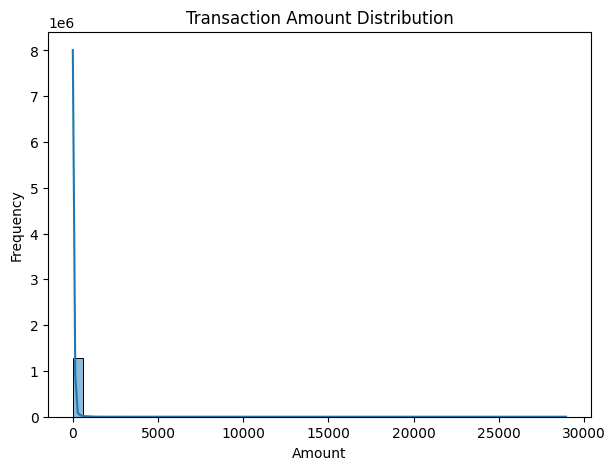

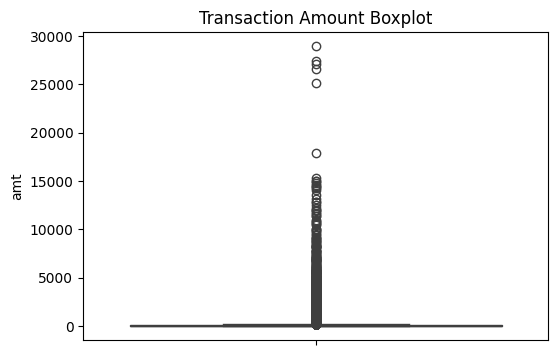

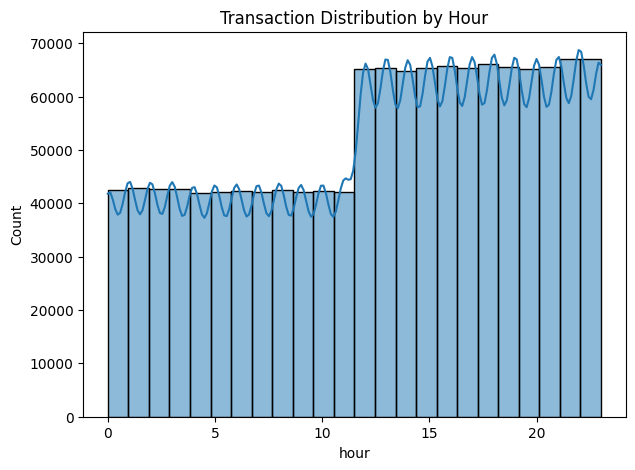


Bivariate Analysis


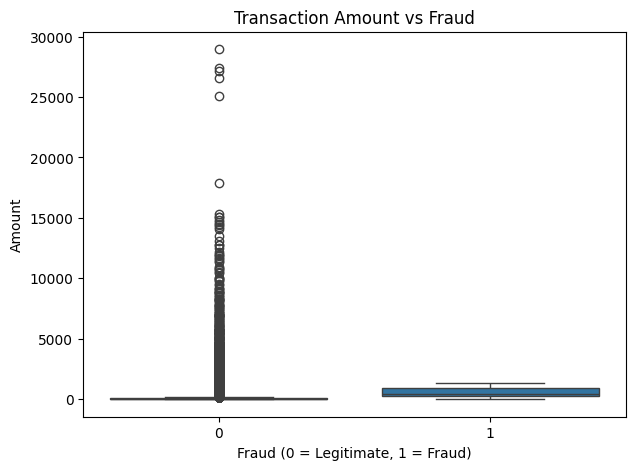

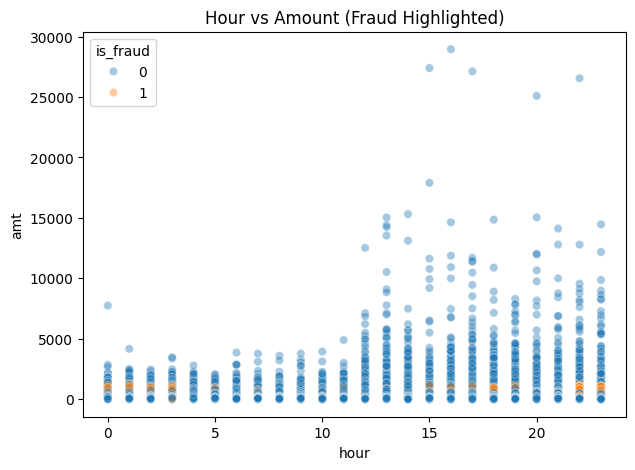


Multivariate Analysis


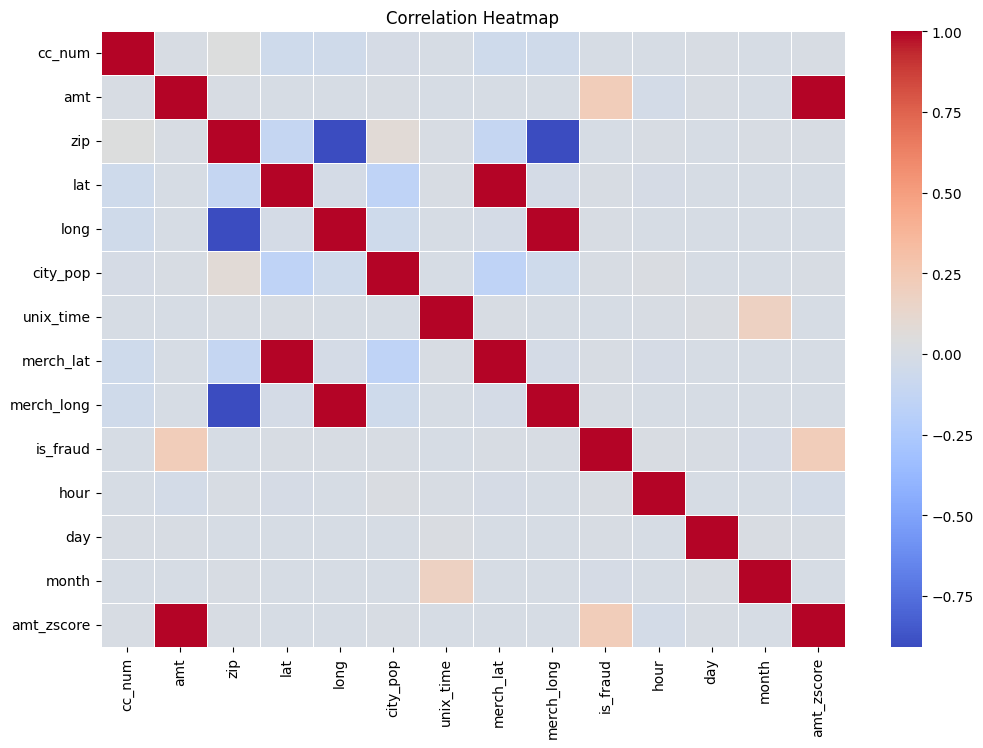

In [5]:
print("Week - 04")

print("\nUnivariate Analysis")

plt.figure(figsize=(7,5))
sns.histplot(df['amt'], bins=50, kde=True)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(y=df['amt'])
plt.title("Transaction Amount Boxplot")
plt.show()

plt.figure(figsize=(7,5))
sns.histplot(df['hour'], bins=24, kde=True)
plt.title("Transaction Distribution by Hour")
plt.show()

print("\nBivariate Analysis")

plt.figure(figsize=(7,5))
sns.boxplot(x='is_fraud', y='amt', data=df)
plt.title("Transaction Amount vs Fraud")
plt.xlabel("Fraud (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Amount")
plt.show()

plt.figure(figsize=(7,5))
sns.scatterplot(
    x='hour',
    y='amt',
    hue='is_fraud',
    data=df,
    alpha=0.4
)
plt.title("Hour vs Amount (Fraud Highlighted)")
plt.show()

print("\nMultivariate Analysis")

numeric_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(12,8))
sns.heatmap(df[numeric_cols].corr(), cmap='coolwarm', linewidths=0.4)
plt.title("Correlation Heatmap")
plt.show()